In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
import os, sys, glob, shutil
import numpy as np, pandas as pd

# 1. Find the code inside the attached dataset
hits = glob.glob("/kaggle/input/**/src/config.py", recursive=True)
print("found:", hits)
assert hits, "config.py not found - the code dataset may not be unzipped"
SRC = os.path.dirname(hits[0])
ROOT = os.path.dirname(SRC)

# 2. /kaggle/input is read-only, so send outputs to the working folder
os.makedirs("/kaggle/working/results/figures", exist_ok=True)
os.environ["RESULTS_DIR"] = "/kaggle/working/results"
os.environ["MODELS_DIR"] = "/kaggle/working/models"
os.environ["RESULTS_CSV"] = "/kaggle/working/results/results.csv"

# 3. Start from his logged rows so we append to the shared file
repo_log = os.path.join(ROOT, "results", "results.csv")
work_log = "/kaggle/working/results/results.csv"
if os.path.exists(repo_log) and not os.path.exists(work_log):
    shutil.copy(repo_log, work_log)

# 4. Import his modules
sys.path.insert(0, SRC)
import config as C
from binning import make_bands
from data import load_dataset

print(C.describe())
splits = load_dataset()
for name, d in splits.items():
    print(f"{name:>5}: {d.shape}")

# 5. Do his fixed bands agree with the band column in split.csv?
all_df = pd.concat(splits.values(), ignore_index=True)
labels, spec = make_bands(all_df["cites_2yr"], verbose=False)
print(spec)
print("agreement with split.csv bands:", (np.asarray(labels.codes) == all_df["band"].values).mean())
print("rows already in shared log:", len(pd.read_csv(work_log)))

found: ['/kaggle/input/datasets/tharunganesh172/citation-code/citation-classification-main/src/config.py']
seed=42 bands=4(fixed) years=2019-2023 window=2y split=data/split.csv kaggle=True
train: (30797, 10)
  val: (6600, 10)
 test: (6600, 10)
BandSpec[fixed](Uncited=(0, 0], Low=(0, 2], Medium=(2, 7], High=(7, inf])
agreement with split.csv bands: 1.0
rows already in shared log: 6


In [2]:
import time
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score
from features import build_features
from metrics import evaluate, log_result

LABELS = spec.labels                       # Uncited, Low, Medium, High
names = dict(enumerate(LABELS))
dev = pd.concat([splits["train"], splits["val"]], ignore_index=True)
y_dev = dev["band"].map(names)

strat = dev["band"].astype(str) + "_" + dev["year"].astype(str)
folds = list(StratifiedKFold(5, shuffle=True, random_state=C.SEED).split(dev, strat))

RUN = ["B3_meta_only"]                     # timing test first

for fs in RUN:
    t0 = time.time()
    oof = np.empty(len(dev), dtype=object)
    fold_f1 = []
    for k, (tr, va) in enumerate(folds, 1):
        model = Pipeline([
            ("feat", build_features(**C.FEATURE_SETS[fs])),
            ("clf", LogisticRegression(max_iter=2000)),
        ])
        model.fit(dev.iloc[tr], y_dev.iloc[tr])
        p = model.predict(dev.iloc[va])
        oof[va] = p
        fold_f1.append(f1_score(y_dev.iloc[va], p, average="macro"))
        print(f"  {fs} fold {k}/5: macro-F1 {fold_f1[-1]:.4f}  ({time.time()-t0:.0f}s)")

    res = evaluate(y_dev, oof, labels=LABELS, y_train=y_dev,
                   model_name=f"LogReg / {fs} (5-fold CV)",
                   feature_set=fs, eval_split="cv", verbose=True)
    log_result(res, notes=(f"5-fold CV on train+val, seed 42, pooled out-of-fold "
                           f"predictions; fold macro-F1 mean {np.mean(fold_f1):.4f} "
                           f"std {np.std(fold_f1):.4f}"))
    print(f"\n{fs} done in {time.time()-t0:.0f}s")

  B3_meta_only fold 1/5: macro-F1 0.4196  (2s)
  B3_meta_only fold 2/5: macro-F1 0.4266  (3s)
  B3_meta_only fold 3/5: macro-F1 0.4227  (4s)
  B3_meta_only fold 4/5: macro-F1 0.4301  (6s)
  B3_meta_only fold 5/5: macro-F1 0.4341  (7s)

  LogReg / B3_meta_only (5-fold CV)
  accuracy           0.4456    (majority baseline 0.2653, lift +0.1803)
  macro F1           0.4266    (majority baseline 0.1048, lift +0.3218)
  balanced accuracy  0.4434
  weighted F1        0.4286
  random guess       0.2500  (4 classes, n=37,397)

  >> Beats the majority baseline on both accuracy and macro F1.

  per class:
    Uncited        precision 0.535  recall 0.620  f1 0.575  n=9920
    Low            precision 0.332  recall 0.187  f1 0.239  n=9031
    Medium         precision 0.348  recall 0.346  f1 0.347  n=9550
    High           precision 0.487  recall 0.620  f1 0.546  n=8896

  confusion matrix (rows = true, cols = predicted):
                  pred Uncited  pred Low  pred Medium  pred High
    true Unc

In [4]:
RUN = ["B1_title_only", "A2_no_venue", "A3_venue_only", "A1_all"]

for fs in RUN:
    t0 = time.time()
    oof = np.empty(len(dev), dtype=object)
    fold_f1 = []
    for k, (tr, va) in enumerate(folds, 1):
        model = Pipeline([
            ("feat", build_features(**C.FEATURE_SETS[fs])),
            ("clf", LogisticRegression(max_iter=2000)),
        ])
        model.fit(dev.iloc[tr], y_dev.iloc[tr])
        p = model.predict(dev.iloc[va])
        oof[va] = p
        fold_f1.append(f1_score(y_dev.iloc[va], p, average="macro"))
        print(f"  {fs} fold {k}/5: macro-F1 {fold_f1[-1]:.4f}  ({time.time()-t0:.0f}s)")

    res = evaluate(y_dev, oof, labels=LABELS, y_train=y_dev,
                   model_name=f"LogReg / {fs} (5-fold CV)",
                   feature_set=fs, eval_split="cv", verbose=False)
    log_result(res, notes=(f"5-fold CV on train+val, seed 42, pooled out-of-fold "
                           f"predictions; fold macro-F1 mean {np.mean(fold_f1):.4f} "
                           f"std {np.std(fold_f1):.4f}"))
    print(f"{fs}: macro-F1 {res['macro_f1']:.4f}, accuracy {res['accuracy']:.4f} "
          f"({time.time()-t0:.0f}s)\n")

from metrics import results_table
t = results_table()
print(t[t["eval_split"] == "cv"][["feature_set", "accuracy", "macro_f1",
                                   "f1_Uncited", "f1_Low", "f1_Medium", "f1_High"]].to_string(index=False))

  B1_title_only fold 1/5: macro-F1 0.3757  (36s)
  B1_title_only fold 2/5: macro-F1 0.3690  (73s)
  B1_title_only fold 3/5: macro-F1 0.3752  (115s)
  B1_title_only fold 4/5: macro-F1 0.3655  (151s)
  B1_title_only fold 5/5: macro-F1 0.3724  (187s)
  logged to /kaggle/working/results/results.csv
B1_title_only: macro-F1 0.3715, accuracy 0.3767 (188s)

  A2_no_venue fold 1/5: macro-F1 0.4251  (60s)
  A2_no_venue fold 2/5: macro-F1 0.4316  (117s)
  A2_no_venue fold 3/5: macro-F1 0.4176  (171s)
  A2_no_venue fold 4/5: macro-F1 0.4198  (229s)
  A2_no_venue fold 5/5: macro-F1 0.4272  (284s)
  logged to /kaggle/working/results/results.csv
A2_no_venue: macro-F1 0.4243, accuracy 0.4317 (285s)

  A3_venue_only fold 1/5: macro-F1 0.3890  (1s)
  A3_venue_only fold 2/5: macro-F1 0.3758  (3s)
  A3_venue_only fold 3/5: macro-F1 0.3891  (4s)
  A3_venue_only fold 4/5: macro-F1 0.3775  (6s)
  A3_venue_only fold 5/5: macro-F1 0.3928  (7s)
  logged to /kaggle/working/results/results.csv
A3_venue_only: macr

test: (6600, 10) | train+val: (37397, 10)
  logged to /kaggle/working/results/results.csv
B3_meta_only: test macro-F1 0.4229, accuracy 0.4429 (2s)
  logged to /kaggle/working/results/results.csv
A2_no_venue: test macro-F1 0.4197, accuracy 0.4292 (68s)
  logged to /kaggle/working/results/results.csv
A3_venue_only: test macro-F1 0.3898, accuracy 0.4200 (2s)
  logged to /kaggle/working/results/results.csv
A1_all: test macro-F1 0.4498, accuracy 0.4585 (69s)


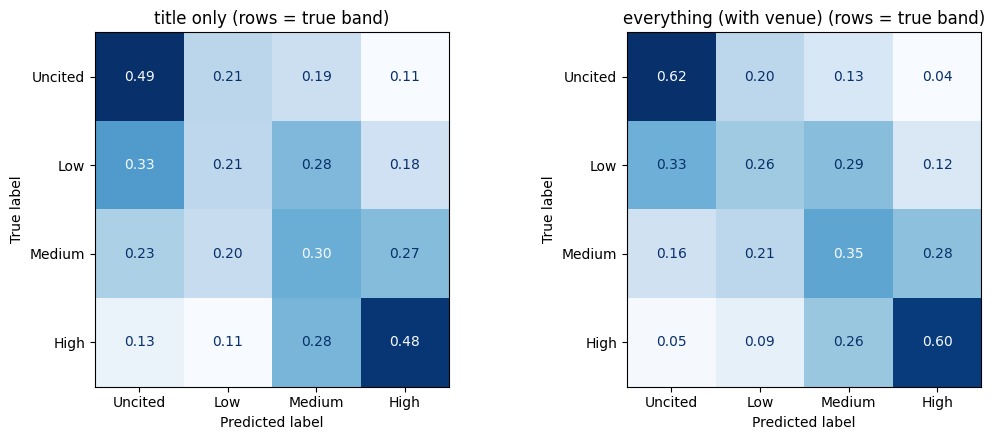

  feature_set  accuracy  macro_f1  f1_Uncited  f1_Low  f1_Medium  f1_High
       A1_all    0.4585    0.4498      0.5869  0.2864     0.3511   0.5746
 B3_meta_only    0.4429    0.4229      0.5713  0.2179     0.3513   0.5512
  A2_no_venue    0.4292    0.4197      0.5446  0.2556     0.3383   0.5405
A3_venue_only    0.4200    0.3898      0.5561  0.1997     0.3392   0.4644
B1_title_only    0.3676    0.3612      0.4542  0.2401     0.2938   0.4568


In [5]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from metrics import results_table

test = splits["test"]
y_test = test["band"].map(names)
print("test:", test.shape, "| train+val:", dev.shape)

preds = {}
for fs in ["B1_title_only", "B3_meta_only", "A2_no_venue", "A3_venue_only", "A1_all"]:
    t0 = time.time()
    model = Pipeline([
        ("feat", build_features(**C.FEATURE_SETS[fs])),
        ("clf", LogisticRegression(max_iter=2000)),
    ])
    model.fit(dev, y_dev)
    preds[fs] = model.predict(test)

    if fs != "B1_title_only":      # his demo row already covers B1 on test
        res = evaluate(y_test, preds[fs], labels=LABELS, y_train=y_dev,
                       model_name=f"LogReg / {fs} (final test)",
                       feature_set=fs, eval_split="test", verbose=False)
        log_result(res, notes="final test: fit on train+val, scored once on test, seed 42")
        print(f"{fs}: test macro-F1 {res['macro_f1']:.4f}, accuracy {res['accuracy']:.4f} "
              f"({time.time()-t0:.0f}s)")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, fs, title in zip(axes, ["B1_title_only", "A1_all"],
                         ["title only", "everything (with venue)"]):
    cm = confusion_matrix(y_test, preds[fs], labels=LABELS, normalize="true")
    ConfusionMatrixDisplay(cm, display_labels=LABELS).plot(
        ax=ax, cmap="Blues", values_format=".2f", colorbar=False)
    ax.set_title(title + " (rows = true band)")
plt.tight_layout()
plt.savefig("/kaggle/working/results/figures/confusion_matrices_final.png", dpi=150)
plt.show()

tab = results_table()
tab = tab[tab["eval_split"] == "test"]
print(tab[["feature_set", "accuracy", "macro_f1", "f1_Uncited", "f1_Low",
           "f1_Medium", "f1_High"]].to_string(index=False))